# 06. Процесс Орнштейна — Уленбека

**Статус:** завершено

Процесс Орнштейна — Уленбека (OU) — базовая непрерывная модель возврата к среднему. В этом ноутбуке мы разберём математику, интуицию, стационарность, автокорреляцию, время полураспада, влияние параметров и отличие от броуновского движения.

## Модель и смысл параметров

OU задаётся SDE

$$dX_t=\kappa(\theta-X_t)dt+\sigma dW_t.$$

Здесь $\theta$ — долгосрочное среднее, $\kappa$ — скорость возврата к нему, $\sigma$ — сила случайных шоков. Если $X_t>\theta$, дрейф отрицателен; если $X_t<\theta$, дрейф положителен. Поэтому процесс не «убегает» как броуновское движение, а постоянно тянется назад.

Точные моменты:

$$\mathbb E[X_t]=\theta+(X_0-\theta)e^{-\kappa t},$$

$$\mathrm{Var}(X_t)=\frac{\sigma^2}{2\kappa}(1-e^{-2\kappa t}).$$

Стационарное распределение:

$$X_\infty\sim N\left(\theta,\frac{\sigma^2}{2\kappa}\right).$$

Время полураспада отклонения от среднего равно $\log 2/\kappa$: за это время среднее отклонение уменьшается вдвое.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
project_root = Path.cwd().resolve()
while not (project_root / "Scripts").exists():
    if project_root.parent == project_root:
        raise RuntimeError("Не удалось найти корень проекта с папкой Scripts.")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)

from Scripts.ornstein_uhlenbeck import (
    calculate_empirical_mean_variance_and_autocorrelation,
    calculate_ornstein_uhlenbeck_half_life,
    calculate_ornstein_uhlenbeck_stationary_standard_deviation,
    calculate_theoretical_ornstein_uhlenbeck_mean_and_variance,
    plot_ornstein_uhlenbeck_mean_variance_comparison,
    plot_ornstein_uhlenbeck_parameter_scenarios,
    plot_ornstein_uhlenbeck_paths_with_mean,
    plot_ornstein_uhlenbeck_stationary_distribution,
    simulate_multiple_ornstein_uhlenbeck_paths_euler,
    simulate_multiple_ornstein_uhlenbeck_paths_exact,
)

## 1. Возврат к среднему на траекториях

,Показатель,Значение
0,E[X(5)] симуляция,0.0133
1,E[X(5)] теория,0.0018
2,Var[X(5)] симуляция,0.1734
3,Var[X(5)] теория,0.1750
4,lag-10 автокорреляция,0.9317
5,half-life,0.4951
6,стационарное std,0.4183


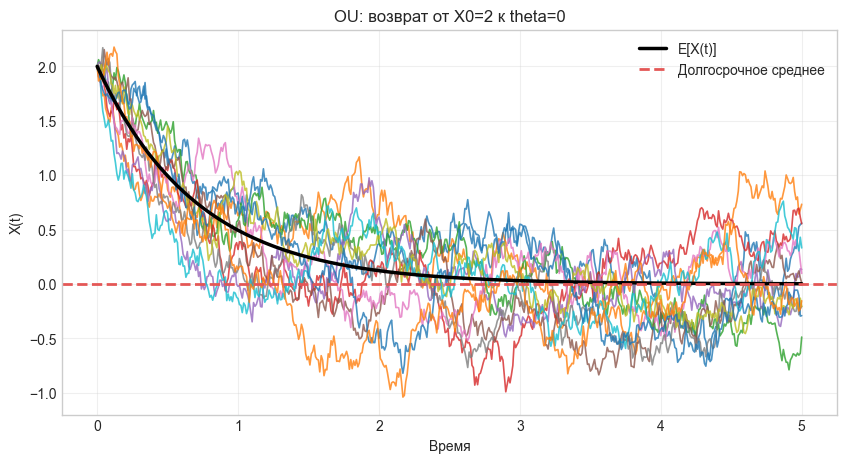

In [2]:
time_grid, ou_paths = simulate_multiple_ornstein_uhlenbeck_paths_exact(
    number_of_paths=5000,
    number_of_time_steps=500,
    final_time=5.0,
    initial_value=2.0,
    mean_reversion_speed=1.4,
    long_term_mean=0.0,
    volatility=0.7,
    random_seed=123,
)
theoretical_mean, theoretical_variance = calculate_theoretical_ornstein_uhlenbeck_mean_and_variance(
    time_grid, 2.0, 1.4, 0.0, 0.7
)
empirical_mean, empirical_variance, lag10_autocorrelation = calculate_empirical_mean_variance_and_autocorrelation(ou_paths, lag=10)

plot_ornstein_uhlenbeck_paths_with_mean(time_grid, ou_paths, theoretical_mean, 0.0, 12, "OU: возврат от X0=2 к theta=0");

pd.DataFrame({
    "Показатель": ["E[X(5)] симуляция", "E[X(5)] теория", "Var[X(5)] симуляция", "Var[X(5)] теория", "lag-10 автокорреляция", "half-life", "стационарное std"],
    "Значение": [ou_paths[:,-1].mean(), theoretical_mean[-1], ou_paths[:,-1].var(), theoretical_variance[-1], lag10_autocorrelation, calculate_ornstein_uhlenbeck_half_life(1.4), calculate_ornstein_uhlenbeck_stationary_standard_deviation(1.4,0.7)]
})

Среднее к моменту `T=5` почти вернулось к нулю: симуляция даёт `0.0133`, теория `0.0018`. Дисперсия `0.1734` близка к теоретической `0.1750` и уже почти равна стационарной дисперсии. Это ключевая разница с броуновским движением: неопределённость не растёт бесконечно, а выходит на плато.

Lag-10 автокорреляция около `0.9317`: соседние по времени значения сильно связаны. OU не забывает состояние мгновенно, но скорость забывания конечна и задаётся $\kappa$. Half-life `0.4951` означает, что среднее отклонение от нуля примерно вдвое уменьшается за половину единицы времени.

## 2. Моменты и стационарное распределение

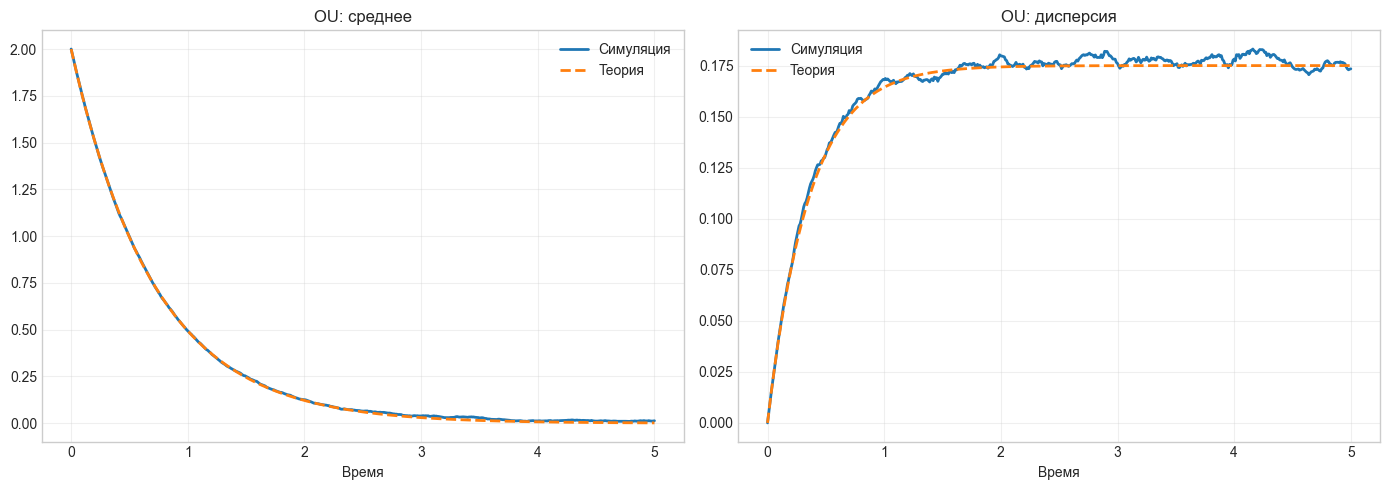

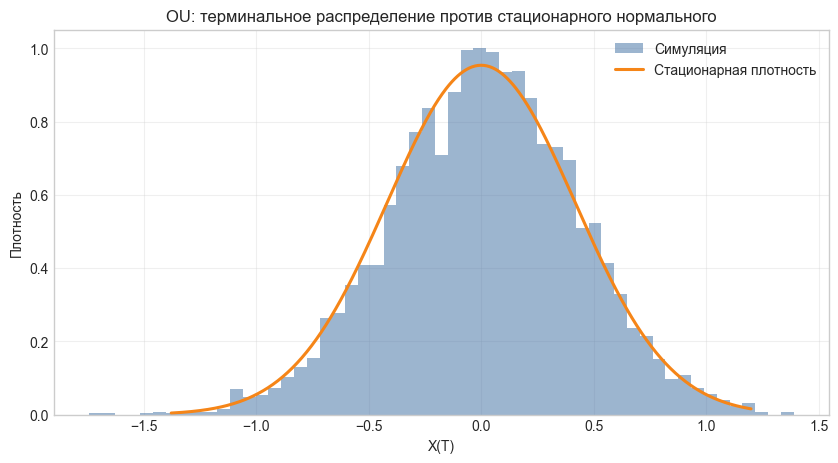

In [3]:
plot_ornstein_uhlenbeck_mean_variance_comparison(
    time_grid, empirical_mean, empirical_variance, theoretical_mean, theoretical_variance, "OU"
);
stationary_std = calculate_ornstein_uhlenbeck_stationary_standard_deviation(1.4, 0.7)
plot_ornstein_uhlenbeck_stationary_distribution(
    terminal_values=ou_paths[:, -1],
    long_term_mean=0.0,
    stationary_std=stationary_std,
    title="OU: терминальное распределение против стационарного нормального"
);

График среднего показывает экспоненциальный спад: сначала возврат быстрый, затем остаточное отклонение становится маленьким. График дисперсии показывает насыщение: случайные шоки постоянно добавляют разброс, но mean reversion постоянно его сжимает.

Гистограмма терминальных значений уже близка к стационарному нормальному распределению. Интуитивно процесс к моменту `T=5` почти «забыл» старт `X0=2`, и его состояние определяется балансом между шумом $\sigma dW_t$ и силой возврата $\kappa(\theta-X_t)dt$.

## 3. Влияние скорости возврата и волатильности

,Сценарий,E[X(5)],Var[X(5)]
0,"медленный возврат, sigma=0.7",0.3096,0.6691
1,"быстрый возврат, sigma=0.7",-0.0056,0.1264
2,"быстрый возврат, sigma=1.2",-0.0097,0.3715


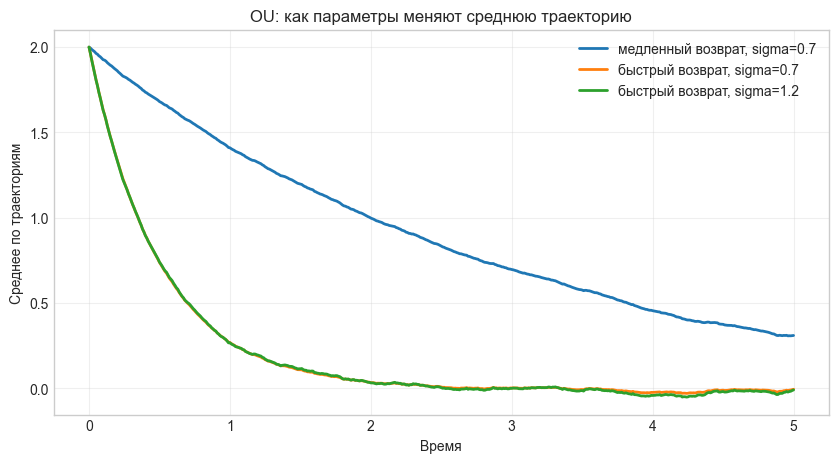

In [4]:
scenario_paths = {}
for name, kappa, sigma in [
    ("медленный возврат, sigma=0.7", 0.35, 0.7),
    ("быстрый возврат, sigma=0.7", 2.0, 0.7),
    ("быстрый возврат, sigma=1.2", 2.0, 1.2),
]:
    scenario_time, scenario_values = simulate_multiple_ornstein_uhlenbeck_paths_exact(
        2500, 500, 5.0, 2.0, kappa, 0.0, sigma, random_seed=77
    )
    scenario_paths[name] = (scenario_time, scenario_values)

plot_ornstein_uhlenbeck_parameter_scenarios(scenario_paths, "OU: как параметры меняют среднюю траекторию");

pd.DataFrame([
    {"Сценарий": name, "E[X(5)]": values[:, -1].mean(), "Var[X(5)]": values[:, -1].var()}
    for name, (_, values) in scenario_paths.items()
])

Большая $\kappa$ быстрее возвращает среднюю траекторию к $\theta$. Волатильность $\sigma$ почти не меняет детерминированную среднюю, но резко увеличивает стационарный разброс. Поэтому в прикладных задачах эти параметры отвечают за разные эффекты: $\kappa$ — за скорость исправления отклонения, $\sigma$ — за ширину коридора вокруг среднего.

## Выводы

1. OU — модель стационарного шума с возвратом к среднему.
2. Среднее возвращается к $\theta$ экспоненциально, а дисперсия выходит на конечный уровень.
3. Half-life даёт удобную интерпретацию скорости возврата.
4. В отличие от броуновского движения OU не имеет бесконечно растущей дисперсии.
5. Модель хорошо подходит для спредов, процентных ставок в простых моделях и ошибок равновесия, но допускает отрицательные значения, что не всегда приемлемо.